# Hafta 1 · Ders 2 — Normlar, Nokta Çarpımları ve İzdüşümler

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Ders 1'de bir vektör, koordinatları olan bir oktu. Şimdi vektörler üzerindeki en önemli iki
*ölçümü* kesinleştiriyoruz:

- **Bir vektör ne kadar uzun?** → **norm** (mesafe/büyüklük kavramı)
- **İki vektör ne kadar hizalı?** → **nokta çarpımı** (benzerlik/açı kavramı)

Bu iki fikir, tüm kursta en çok yeniden kullanılan işlem olan **izdüşüm** (bir vektörü diğerinin
üzerine düşürme) içinde birleşir. En küçük kareler (Hafta 3), Gram–Schmidt (Hafta 4)
ve PCA (Hafta 6) *hepsi* kılık değiştirmiş izdüşümdür.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import plot_vectors_2d, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Normlar — uzunluğu ölçmek

Bir **norm** $\lVert \cdot \rVert$, her vektöre negatif olmayan bir uzunluk atar. Zaten
bildiğiniz norm, **Öklid (L2) normudur**:

$$ \lVert \mathbf{v} \rVert_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2} = \sqrt{\mathbf{v}^\top \mathbf{v}} $$

Ama tek norm bu değil. Makine öğrenmesinde sürekli karşımıza çıkan iki norm daha vardır:

$$ \lVert \mathbf{v} \rVert_1 = \sum_i |v_i| \quad\text{(L1, "taksi mesafesi")} \qquad
   \lVert \mathbf{v} \rVert_\infty = \max_i |v_i| \quad\text{(L∞, "maksimum")} $$

L1, **Lasso**yu (seyrek modeller) yönlendirir; L2, **ridge** regresyonunu ve ağırlık sönümünü (weight decay) yönlendirir. Hadi
üçünü de sıfırdan uygulayalım — `np.linalg.norm` yok.

In [2]:
def lp_norm(v, p=2):
    v = np.asarray(v, dtype=float)
    if p == np.inf:
        return np.max(np.abs(v))
    return np.sum(np.abs(v) ** p) ** (1.0 / p)

v = np.array([3.0, -4.0])
for p, name in [(1, "L1"), (2, "L2"), (np.inf, "L∞")]:
    print(f"{v} vektörünün {name:<3} normu = {lp_norm(v, p):.3f}")

# numpy ile doğrula
check("L1",  lp_norm(v, 1),      np.linalg.norm(v, 1))
check("L2",  lp_norm(v, 2),      np.linalg.norm(v, 2))
check("Linf", lp_norm(v, np.inf), np.linalg.norm(v, np.inf))

L1  norm of [ 3. -4.] = 7.000
L2  norm of [ 3. -4.] = 5.000
L∞  norm of [ 3. -4.] = 4.000
[PASS] L1                               max|Δ| = 0.00e+00
[PASS] L2                               max|Δ| = 0.00e+00
[PASS] Linf                             max|Δ| = 0.00e+00


True

### Her normun "birim topunu" görselleştirmek

Normu $= 1$ olan tüm vektörlerin kümesi her norm için farklı görünür. Bu tek resim,
L1'in *neden* seyrek çözümler ürettiğini açıklar: birim topunun eksenler üzerinde keskin köşeleri vardır, bu yüzden
optimize ediciler bazı koordinatların tam olarak sıfır olduğu çözümlere doğru çekilir.

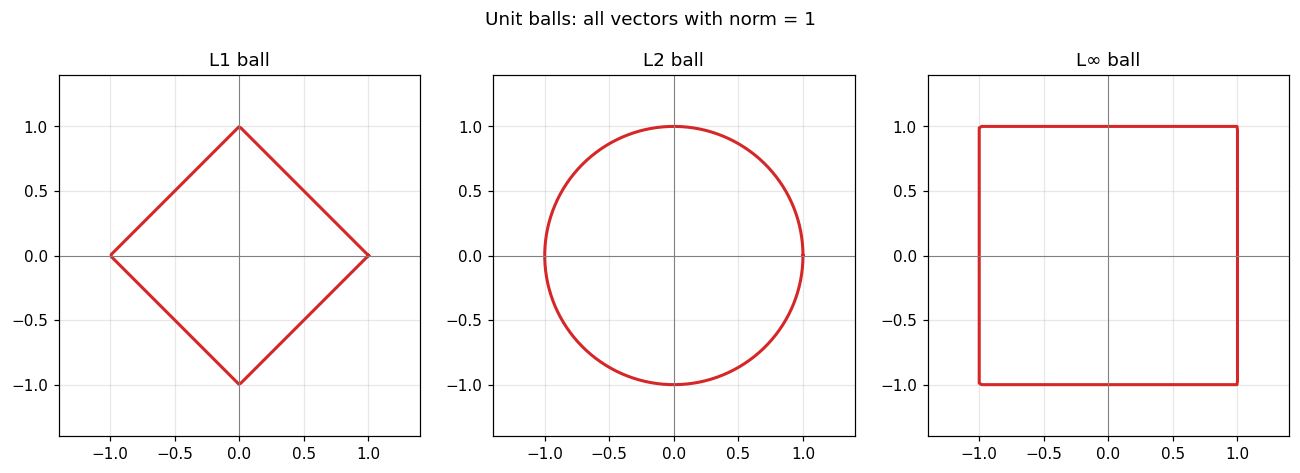

In [3]:
th = np.linspace(0, 2*np.pi, 400)
pts = np.stack([np.cos(th), np.sin(th)])   # yönler

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (p, name) in zip(axes, [(1, "L1 topu"), (2, "L2 topu"), (np.inf, "L∞ topu")]):
    # her yönü, normu tam olarak 1 olacak şekilde ölçekle
    scaled = np.array([d / lp_norm(d, p) for d in pts.T]).T
    ax.plot(scaled[0], scaled[1], color="C3", lw=2)
    ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_title(name)
plt.suptitle("Birim toplar: normu = 1 olan tüm vektörler", y=1.02)
plt.tight_layout(); plt.show()

## 2. Nokta çarpımı — hizalanmayı ölçmek

İki vektörün **nokta çarpımı** şudur

$$ \mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i = \lVert \mathbf{a}\rVert\,\lVert \mathbf{b}\rVert \cos\theta $$

O ikinci eşitlik anahtardır: nokta çarpımı, **uzunluk** ve **açı**yı bir arada paketler.
Yeniden düzenlersek, herhangi iki vektör arasındaki açıyı elde ederiz — bu, kelime gömmelerinden
öneri sistemlerine kadar her yerde kullanılan **kosinüs benzerliğinin** temelidir.

$$ \cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert} $$

Üç durum önemlidir: $\mathbf{a}\cdot\mathbf{b} > 0$ (hizalı), $= 0$ (**ortogonal**), $< 0$ (zıt).

In [4]:
def dot(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.sum(a * b)

def angle_between(a, b):
    cos = dot(a, b) / (lp_norm(a) * lp_norm(b))
    cos = np.clip(cos, -1.0, 1.0)          # küçük float taşmalarına karşı koru
    return np.degrees(np.arccos(cos))

pairs = [([1, 0], [1, 1]), ([1, 0], [0, 1]), ([1, 0], [-1, 1])]
for a, b in pairs:
    print(f"a={a}, b={b}:  nokta={dot(a,b):+.1f}   açı={angle_between(a,b):5.1f}°")

check("nokta çarpımı", dot([1, 2, 3], [4, 5, 6]), np.dot([1, 2, 3], [4, 5, 6]))

a=[1, 0], b=[1, 1]:  dot=+1.0   angle= 45.0°
a=[1, 0], b=[0, 1]:  dot=+0.0   angle= 90.0°
a=[1, 0], b=[-1, 1]:  dot=-1.0   angle=135.0°
[PASS] dot product                      max|Δ| = 0.00e+00


True

## 3. İzdüşüm — beygir gücü

$\mathbf{a}$ ve $\mathbf{b}$ vektörleri verildiğinde, **$\mathbf{a}$'nın $\mathbf{b}$ üzerine izdüşümü**,
$\mathbf{a}$'nın $\mathbf{b}$ yönünde oluşturduğu "gölge"dir:

$$ \text{proj}_{\mathbf{b}}(\mathbf{a}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}\,\mathbf{b} $$

Artakalan parça, $\mathbf{a} - \text{proj}_{\mathbf{b}}(\mathbf{a})$, $\mathbf{b}$'ye **ortogonaldir**.
Bu ayrışım — "$\mathbf{b}$ boyunca olan parça" artı "$\mathbf{b}$'ye dik olan parça" — en küçük karelerin
hedefi, bir modelin açıklayabildiği parça ile açıklayamadığı kalıntıya böldüğünde
*tam olarak* yaptığı şeydir.

proj_b(a) = [3.529 0.882]
residual  = [-0.529  2.118]
residual · b = 0.0  → orthogonal (≈0)


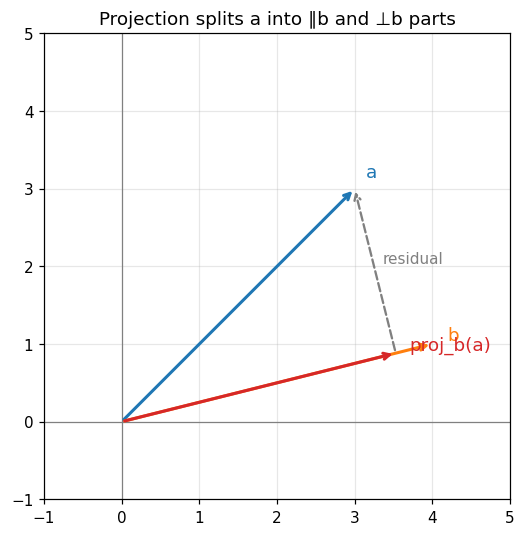

In [5]:
def project(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return (dot(a, b) / dot(b, b)) * b

a = np.array([3.0, 3.0])
b = np.array([4.0, 1.0])
p = project(a, b)
resid = a - p

print("proj_b(a) =", p)
print("kalıntı   =", resid)
print("kalıntı · b =", round(dot(resid, b), 12), " → ortogonal (≈0)")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
plot_vectors_2d([a, b, p], colors=["C0", "C1", "C3"],
                labels=["a", "b", "proj_b(a)"], ax=ax, lim=(-1, 5))
# izdüşümün ucundan a'ya kadar kesik çizgili kalıntı
ax.annotate("", xy=a, xytext=p, arrowprops=dict(arrowstyle="->", color="grey", ls="--", lw=1.5))
ax.text(*(p + resid/2 + 0.1), "kalıntı", color="grey", fontsize=10)
ax.set_title("İzdüşüm, a'yı ∥b ve ⊥b parçalarına böler")
plt.show()

## 4. Bunun makine öğrenmesinde karşımıza çıktığı yer

- Gömmeler arasındaki **kosinüs benzerliği**, yalnızca normalleştirilmiş vektörlerin nokta çarpımıdır —
  aramada, RAG'de ve önerilerde geri getirme (retrieval) adımı.
- **L1'e karşı L2 düzenlileştirmesi**, kelimenin tam anlamıyla ağırlık vektörünün L1 ve L2 normlarına uygulanan cezalardır;
  yukarıdaki birim-top resmi, L1'in *neden* seyrek modeller ürettiğidir.
- **En küçük kareler = izdüşüm.** Lineer bir model uydurmak, hedef $\mathbf{y}$'yi verinin
  sütun uzayına izdüşürür — bunu Ders 6'da tam olarak türeteceğiz.

Hadi küçük "belge" vektörleri üzerinde kosinüs benzerliğinin ön gösterimini yapalım.

In [6]:
def cosine_similarity(a, b):
    return dot(a, b) / (lp_norm(a) * lp_norm(b))

# satırlar = belgeler, sütunlar = ["kedi", "köpek", "finans"] için kelime sayıları
docs = {
    "evcil hayvan makalesi A":     np.array([4.0, 3.0, 0.0]),
    "evcil hayvan makalesi B":     np.array([3.0, 5.0, 1.0]),
    "finans makalesi":   np.array([0.0, 1.0, 6.0]),
}
names = list(docs)
print("Belgeler arasındaki kosinüs benzerliği:\n")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        s = cosine_similarity(docs[names[i]], docs[names[j]])
        print(f"  {names[i]:<24} vs {names[j]:<24}: {s:.3f}")

Cosine similarity between documents:

  pet article A    vs pet article B   : 0.913
  pet article A    vs finance article : 0.099
  pet article B    vs finance article : 0.306


## Alıştırmalar

1. **Üçgen eşitsizliği.** Birkaç rastgele çift için $\lVert \mathbf{a}+\mathbf{b}\rVert \le \lVert\mathbf{a}\rVert + \lVert\mathbf{b}\rVert$ olduğunu sayısal olarak doğrulayın.
2. **Birim vektör.** Aynı yönde 1 uzunluğunda bir vektör döndüren `normalize(v)` fonksiyonunu yazın. `v` sıfır vektörü ise ne bozulur?
3. **İzdüşüm idempotenttir.** `proj_b(a)`'yı `b` üzerine tekrar izdüşürmenin aynı vektörü döndürdüğünü gösterin. Bu neden geometrik olarak anlamlıdır?

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===
rng = np.random.default_rng(1)

# 1.
ok = True
for _ in range(1000):
    a, b = rng.normal(size=2), rng.normal(size=2)
    if lp_norm(a + b) > lp_norm(a) + lp_norm(b) + 1e-9:
        ok = False
print("üçgen eşitsizliği tüm örnekler için sağlanıyor:", ok)

# 2.
def normalize(v):
    n = lp_norm(v)
    if n == 0:
        raise ValueError("sıfır vektörü normalleştirilemez (yönü yok)")
    return np.asarray(v, float) / n
print("normalize([3,4]) =", normalize([3, 4]), " uzunluk =", lp_norm(normalize([3, 4])))

# 3.
a, b = np.array([3., 3.]), np.array([4., 1.])
once = project(a, b)
twice = project(once, b)
print("izdüşüm idempotent:", np.allclose(once, twice))

triangle inequality holds for all samples: True
normalize([3,4]) = [0.6 0.8]  length = 1.0
proj idempotent: True


## Özet ve sırada ne var

Norm = uzunluk, nokta çarpımı = hizalanma, izdüşüm = bir vektörü diğeri boyunca düşürüp
ortogonal bir kalıntı tutmak. Bu üç ölçüm, çıplak bir vektör uzayını, üzerinde hesap
yapabileceğimiz bir *geometriye* dönüştürür.

**Sırada — `03_donusum_olarak_matrisler.ipynb`:** matrisleri sayı ızgaralarından
**uzayı hareket ettiren fonksiyonlara** yükseltiyoruz ve bir 2×2 matrisin tüm bir ızgarayı nasıl büktüğünü izliyoruz.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 1 · Ders 2*